In [17]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load historical loan data - 20 past decisions 
df = pd.read_csv('customer_churn.csv')


print('Dataset shape:', df.shape)
print()
df.head(8)

Dataset shape: (50, 5)



,customer_id,age,monthly_spend,num_complaints,churned
0,CUST-001,60,2324,0,1
1,CUST-002,37,4512,3,0
2,CUST-003,28,12566,1,0
3,CUST-004,54,1924,6,1
4,CUST-005,22,988,1,1
5,CUST-006,33,4311,8,1
6,CUST-007,58,934,8,1
7,CUST-008,32,12231,8,1


In [30]:
# Used to Know What Data to use to predit - To know the Input and Output

# Separate features (X) from the label (y)
# Features = What we know about the applicant 
# Label    = the outcome we want to predict

X = df[['monthly_spend', 'num_complaints']]

y = df['churned']


print('Features (X)- 3 coloums, 50 rows:')
print(X.head(3))
print()
print('Label (y) - what we want to predict:')
print(y.values)
print(f'Approved : {y.sum()} | Rejected : {(y==0).sum()}')

Features (X)- 3 coloums, 50 rows:
   monthly_spend  num_complaints
0           2324               0
1           4512               3
2          12566               1

Label (y) - what we want to predict:
[1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 0
 1 1 1 1 1 0 0 1 1 0 1 1 1]
Approved : 35 | Rejected : 15


In [34]:
# To Train the Model

# split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)} customers')
print(f'Test set: {len(X_test)} customers')
print()

# Train the ML model - it learns the rules from training data
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)                       # <-- this is where learning happens

print('Model trained. It has now seen', len(X_train), 'examples.')
print('It learned patterns - no rules were written by hands.')

Training set: 40 customers
Test set: 10 customers

Model trained. It has now seen 40 examples.
It learned patterns - no rules were written by hands.


In [35]:
# To test if Model as been Trained

# Evaluate on test set - applicants the model has NEVER seen
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Test set predictions vs actual descions:')
print(f'{"Actual":<10} {"ML Predicted":<15} {"Match?"}')
print("-" * 35)
for actual, predicted in zip(y_test, y_pred):
    match = 'YES' if actual == predicted else 'NO'
    label_a = 'APPROVED' if actual    else 'REJECTED'
    label_p = 'APPROVED' if predicted else 'REJECTED'
    print(f'{label_a:<10} {label_p:<15} {match}')

print()
print(f'Accuracy: {accuracy*100:.0f}%')


Test set predictions vs actual descions:
Actual     ML Predicted    Match?
-----------------------------------
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
REJECTED   REJECTED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
REJECTED   REJECTED        YES

Accuracy: 100%


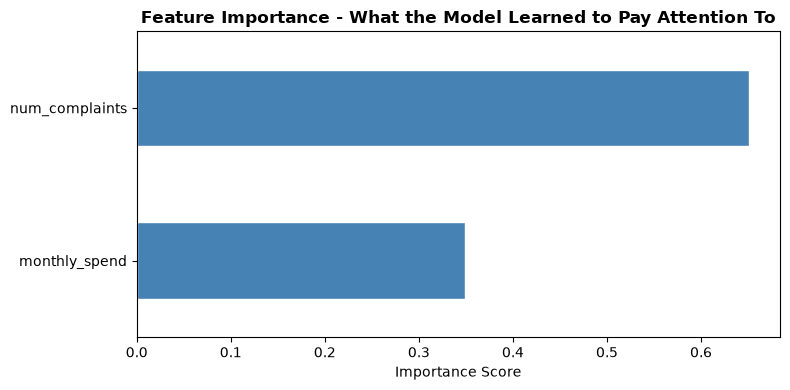

The model assigned importance to each feature based on the training data.
This is the pattern it learned - no human specified these weights.


In [36]:
import matplotlib.pyplot as plt

# Feature importance - which feature mattered most to the model?
importance = pd.Series(
    model.feature_importances_,
    index=['monthly_spend', 'num_complaints']
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance - What the Model Learned to Pay Attention To',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('The model assigned importance to each feature based on the training data.')
print('This is the pattern it learned - no human specified these weights.')